#  **Project : LightGBM**

## **Project:**
- Large Scale Credit Risk Analysis

### **Problem Statement:**
- Analyze credit default risk using massive banking datasets.

In [25]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\sagar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [26]:
# Step No 1 : Import Required Libraries 

# Import pandas for data manipulation
import pandas as pd 

# Import numpy for numerical operations 
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt 

# Import seaborn for visualization 
import seaborn as sns

# Import train_test_split for splitting data 
from sklearn.model_selection import train_test_split

# Import LightGBM classification model
from lightgbm import LGBMClassifier

# Import Evaluation Metrics 
# Import accuracy score 
from sklearn.metrics import accuracy_score

# Import Precision Score 
from sklearn.metrics import precision_score

# Import recall score 
from  sklearn.metrics import recall_score

# Import confusion matrix 
from sklearn.metrics import confusion_matrix

# Import classification report 
from sklearn.metrics import classification_report

# Import ROC - AUC score 
from sklearn.metrics import roc_auc_score

# Import ROC curve
from sklearn.metrics import roc_curve

from sklearn.metrics import f1_score

In [27]:
# Step No 2 : Load Dataset 
# Load the credit risk dataset 
df = pd.read_csv("large_scale_credit_risk_analysis_lightgbm.csv")

In [28]:
# Step No 3 : Data Understanding and Manipulation

# Display number of rows and columns 
print("Rows and Columns : " , df.shape)

# Display first 10 records
df.head(10)

# Display all column names 
print("Column names : ",df.columns)

# Display dataset information
print("data information : " , df.info())

# Display statistical summary of numerical columns 
print("Data Summary : ", df.describe())

Rows and Columns :  (50000, 16)
Column names :  Index(['Customer_ID', 'Age', 'Annual_Income', 'Employment_Years',
       'Credit_Score', 'Credit_Amount', 'Interest_Rate', 'Loan_Term_Months',
       'Existing_Loans', 'Debt_to_Income_Ratio', 'Late_Payments',
       'Credit_Utilization', 'Bank_Account_Balance', 'Previous_Default',
       'Loan_Purpose', 'Default'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           50000 non-null  object 
 1   Age                   50000 non-null  int64  
 2   Annual_Income         50000 non-null  int64  
 3   Employment_Years      50000 non-null  float64
 4   Credit_Score          50000 non-null  int64  
 5   Credit_Amount         50000 non-null  int64  
 6   Interest_Rate         50000 non-null  float64
 7   Loan_Term_Months      50000 non-null  in

In [29]:
# Step No 4 : Data Cleaning 
# Check missing values in each column
print(df.isnull().sum())

# Check total missing values 
print("Total Missing Values : " , df.isnull().sum())

# Check the number of duplicate rows 
print("Duplicate Rows : " , df.duplicated().sum())

#

Customer_ID             0
Age                     0
Annual_Income           0
Employment_Years        0
Credit_Score            0
Credit_Amount           0
Interest_Rate           0
Loan_Term_Months        0
Existing_Loans          0
Debt_to_Income_Ratio    0
Late_Payments           0
Credit_Utilization      0
Bank_Account_Balance    0
Previous_Default        0
Loan_Purpose            0
Default                 0
dtype: int64
Total Missing Values :  Customer_ID             0
Age                     0
Annual_Income           0
Employment_Years        0
Credit_Score            0
Credit_Amount           0
Interest_Rate           0
Loan_Term_Months        0
Existing_Loans          0
Debt_to_Income_Ratio    0
Late_Payments           0
Credit_Utilization      0
Bank_Account_Balance    0
Previous_Default        0
Loan_Purpose            0
Default                 0
dtype: int64
Duplicate Rows :  0


In [30]:
# Step No 5 : Check Target Variable 
# Count each default class
print(df["Default"].value_counts())
# Target meaning 
# 0 = Customer did not default 
# 1 = Customer defaulted 


Default
0    26585
1    23415
Name: count, dtype: int64


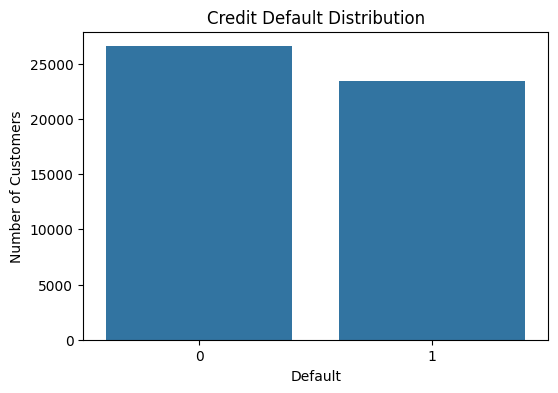

In [31]:
# Step No 6 : Visualize Target Variable 
# Set figure size
plt.figure(figsize=(6, 4))

# Create count plot
sns.countplot(x="Default", data=df)

# Add title
plt.title("Credit Default Distribution")

# Add X-axis label
plt.xlabel("Default")

# Add Y-axis label
plt.ylabel("Number of Customers")

# Display graph
plt.show()

In [32]:
# Step No 7 : Calculate default class percentage 
default_percentage = (
    df["Default"].value_counts(normalize=True) * 100
)
# Display percentage
print(default_percentage)

Default
0    53.17
1    46.83
Name: proportion, dtype: float64


In [33]:
# Step No 8 : Correlation Analysis
# Remove Customer_ID because it is only an identification 
corr_data = df.drop(columns=["Customer_ID"])

# Convert categorical columns into numerical columns
corr_data = pd.get_dummies(
    corr_data,
    drop_first=True
)

# Calculate correlation matrix 
correlation = corr_data.corr()

# Display correlation matrix 
print(correlation)

                             Age  Annual_Income  Employment_Years  \
Age                     1.000000      -0.003122          0.002106   
Annual_Income          -0.003122       1.000000          0.002922   
Employment_Years        0.002106       0.002922          1.000000   
Credit_Score            0.008000       0.004577         -0.001509   
Credit_Amount          -0.000573       0.007805          0.006139   
Interest_Rate          -0.006577      -0.002352         -0.012347   
Loan_Term_Months        0.009731       0.002882          0.001438   
Existing_Loans          0.001193       0.008781          0.001861   
Debt_to_Income_Ratio    0.000716       0.003220         -0.002445   
Late_Payments          -0.009487       0.008186          0.002101   
Credit_Utilization     -0.004109      -0.005045          0.006074   
Bank_Account_Balance   -0.000283       0.003843         -0.003829   
Previous_Default       -0.000135       0.000277         -0.002249   
Default                 0.001801  

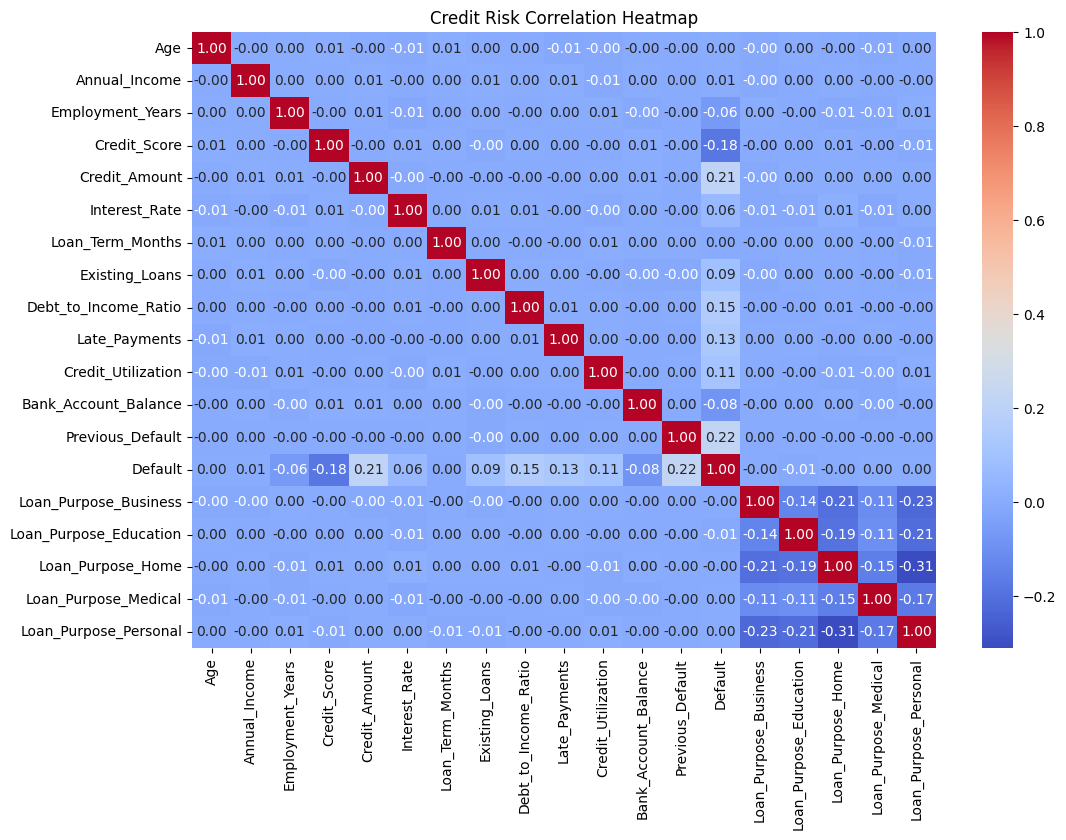

In [34]:
# Step No 9 : Correlation Heatmap 
# Set figure size 
plt.figure(figsize=(12 ,8))

# Create correlation heatmap 
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt = ".2f"
)

# Add title 
plt.title("Credit Risk Correlation Heatmap")

# Display graph
plt.show()

In [35]:
# Step No 10 : Define Feature and Target
# Create input features by removing ID and target 
X = df.drop(
    columns=["Customer_ID" , "Default"]
)

# Create target variable 
y = df["Default"]

# Display feature columns 
print("Features : ")
print(X.columns)

# Display target variable 
print("\nTarget : ")
print(y.name)

Features : 
Index(['Age', 'Annual_Income', 'Employment_Years', 'Credit_Score',
       'Credit_Amount', 'Interest_Rate', 'Loan_Term_Months', 'Existing_Loans',
       'Debt_to_Income_Ratio', 'Late_Payments', 'Credit_Utilization',
       'Bank_Account_Balance', 'Previous_Default', 'Loan_Purpose'],
      dtype='object')

Target : 
Default


In [36]:
# Step No 11 : Feature Engineering 
# Create Loan-to-Income Ratio
# It shows the loan amount compared with annual income
X["Loan_to_Income_Ratio"] = (
    X["Credit_Amount"] / (X["Annual_Income"] + 1)
)

#Create Monthly Income 
# It represents approximate monthly income 
X["Monthly_Income"] = (
    X["Annual_Income"] / 12
)

# Create Monthly Loan Burden
# It represents approximate loan amount per repayment month
X["Monthly_Loan_Burden"] = (
    X["Credit_Amount"] / (X["Loan_Term_Months"] + 1)
)

# Create Credit-to-Balance Ration
#It compares credit amount with bank account balance
X["Credit_to_Balance_Ratio"] = (
    X["Credit_Amount"] / (X["Bank_Account_Balance"] + 1)
)

# Create Late Payment Rate
# It represents late payments relative to existing loans
X["Late_Payment_Rate"] = (
    X["Late_Payments"] / (X["Existing_Loans"] + 1)
)

# Display engineered features 
print(X.head())

   Age  Annual_Income  Employment_Years  Credit_Score  Credit_Amount  \
0   66          37640              11.4           712         183873   
1   23         215439              10.2           605          58251   
2   49         108776               5.2           689         176588   
3   55          79287               0.0           616         256467   
4   59          26182               8.3           794          94355   

   Interest_Rate  Loan_Term_Months  Existing_Loans  Debt_to_Income_Ratio  \
0           6.26                72               1                 0.062   
1          25.38                24               1                 0.335   
2          24.45                12               2                 0.020   
3          16.68                48               2                 0.163   
4          11.36                84               2                 0.537   

   Late_Payments  Credit_Utilization  Bank_Account_Balance  Previous_Default  \
0              0              

In [37]:
# Step No 12 : Check Features After Feature Engineering
# Display all feature names
print("Features after Feature Engineering : ")

# Print feature names 
print(X.columns)

# Display new feature shape 
print("X Shape : ", X.shape)

Features after Feature Engineering : 
Index(['Age', 'Annual_Income', 'Employment_Years', 'Credit_Score',
       'Credit_Amount', 'Interest_Rate', 'Loan_Term_Months', 'Existing_Loans',
       'Debt_to_Income_Ratio', 'Late_Payments', 'Credit_Utilization',
       'Bank_Account_Balance', 'Previous_Default', 'Loan_Purpose',
       'Loan_to_Income_Ratio', 'Monthly_Income', 'Monthly_Loan_Burden',
       'Credit_to_Balance_Ratio', 'Late_Payment_Rate'],
      dtype='object')
X Shape :  (50000, 19)


In [38]:
# Step No 13 : Encode Categorical Features 
# Convert categorical columns into numerical columns
X = pd.get_dummies(
    X,
    columns=["Loan_Purpose"],
    drop_first=True
)

# Display encoded feature columns
print(X.columns)


Index(['Age', 'Annual_Income', 'Employment_Years', 'Credit_Score',
       'Credit_Amount', 'Interest_Rate', 'Loan_Term_Months', 'Existing_Loans',
       'Debt_to_Income_Ratio', 'Late_Payments', 'Credit_Utilization',
       'Bank_Account_Balance', 'Previous_Default', 'Loan_to_Income_Ratio',
       'Monthly_Income', 'Monthly_Loan_Burden', 'Credit_to_Balance_Ratio',
       'Late_Payment_Rate', 'Loan_Purpose_Business', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Medical', 'Loan_Purpose_Personal'],
      dtype='object')


In [39]:
# Step No 14 : Check X and y Shape 
# Display input feature shape 
print("X Shape : " , X.shape)

# Display target shape 
print("y Shape : " , y.shape)

X Shape :  (50000, 23)
y Shape :  (50000,)


In [40]:
# Step No 15 : Train - Test Split 
# Split data into trainin and testing sets 
X_train , X_test , y_train , y_test = train_test_split(
    # Input features 
    X,
    # Target variable 
    y,
    # Use 20% data for testing 
    test_size = 0.20,
    # Set random state for reproducibility
    random_state=42 ,
    # Maintain target class proportion
    stratify=y
)

# Check Train - Test Data 
# Display training feature shape 
print("X_train : ",X_train.shape)

# Display testing feature shape 
print("X_test : ", X_test.shape)

# Display training target shape 
print("y_train : " , y_train.shape)

# Display testing target shape 
print("y_test : ", y_train.shape)

X_train :  (40000, 23)
X_test :  (10000, 23)
y_train :  (40000,)
y_test :  (40000,)


In [41]:
# Step No 16 : Create LightGBM Model
# Create LightGBM classification model
lgbm_model = LGBMClassifier(
    
    # Number of boosting trees 
    n_estimators=200,
    # Learning rate of the model
    learning_rate=0.05,
    # Number of leaves in each tree
    num_leaves=31 ,
    # Maximum depth of the tree
    max_depth=-1,
    # Set random state for reproducibility
    random_state=42,
    # Use all available CPU cores 
    n_jobs=-1
)

In [42]:
# Step No 17 : Train LightGBM Model
# Train the LightGBM model
lgbm_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 18732, number of negative: 21268


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000766 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3157
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.468300 -> initscore=-0.126970
[LightGBM] [Info] Start training from score -0.126970


LGBMClassifier(learning_rate=0.05, n_estimators=200, n_jobs=-1, random_state=42)

In [43]:
# Step No 18 : Make Predictions 
# Make predictions on test data
y_pred = lgbm_model.predict(X_test)

# Display first 20 predictions 
print(y_pred[:20])

[1 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0]


In [44]:
# Step No 19 : Get Prediction Probabilities 
# Calculate Probability of default 
# [: , 1] selects probability of class 1 
y_pred_proba = lgbm_model.predict_proba(
    X_test
)[: , 1]

# Display first 10 probabilities 
print(y_pred_proba[:10])

[0.77637071 0.45521863 0.37887108 0.30756004 0.74335666 0.95363035
 0.4171742  0.38296023 0.36828295 0.36607892]


In [45]:
# Step No 20 : Evalution Metrics 
#Calculate model accuracy 
accuracy = accuracy_score(
    y_test,
    y_pred
)
# Display accuracy 
print("Accuracy : " , accuracy)
# Display accuracy percentage 
print("Accuracy Percentage : ", accuracy * 100)

# Calculate model precision
precision = precision_score(
    y_test,
    y_pred
)
print("Precision:", precision)

# Calculate model recall
recall = recall_score(
    y_test,
    y_pred
)
# Display recall
print("Recall : ", recall)

# Calculate F1 score
f1 = f1_score(
    y_test,
    y_pred
)

# Display F1 score
print("F1 Score:", f1)

# Calculate ROC-AUC score 
roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)
# Display ROC-AUC score 
print("ROC-AUC Score : " , roc_auc)

# Display All Metrics 
# Display model performance heading 
print("============ LIGHTGBM MODEL PERFORMANCE ===========")

# Display accuracy
print("Accuracy : ", round(accuracy , 4))

# Display precision
print("Precision : ", round(precision , 4))

# Display recall
print("Recall : ", round(recall , 4))

# Display F1 score 
print("F1 Score : " , round(f1 , 4))

# Display ROC-AUC score 
print("ROC-AUC : " , round(roc_auc , 4))

# Generate detailed classification report 
report = classification_report(
    y_test,
    y_pred
)
# Display classification report 
print(report)

# Create confusion matrix 
cm = confusion_matrix(
    y_test,
    y_pred
)
# Display confusion matrix 
print(cm)

Accuracy :  0.6872
Accuracy Percentage :  68.72
Precision: 0.6806039488966318
Recall :  0.6256673072816571
F1 Score: 0.6519804183355585
ROC-AUC Score :  0.7504677501497921
============ LIGHTGBM MODEL PERFORMANCE ===========
Accuracy :  0.6872
Precision :  0.6806
Recall :  0.6257
F1 Score :  0.652
ROC-AUC :  0.7505
              precision    recall  f1-score   support

           0       0.69      0.74      0.72      5317
           1       0.68      0.63      0.65      4683

    accuracy                           0.69     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.69      0.69     10000

[[3942 1375]
 [1753 2930]]


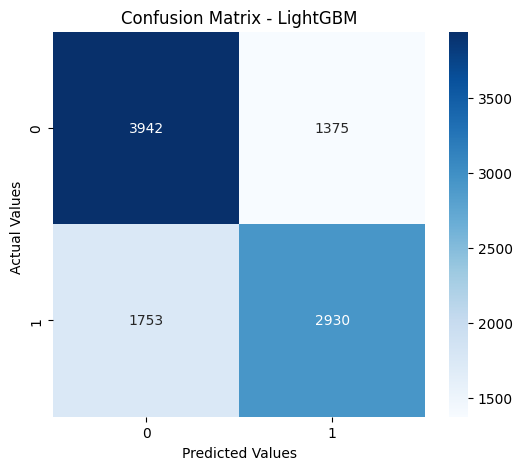

In [46]:
# Step No 21 : Visualize Confusion Matrix 
# Set figure size 
plt.figure(figsize=(6,5))

# Create heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Add title
plt.title("Confusion Matrix - LightGBM")

# Add X-axis label 
plt.xlabel("Predicted Values")

# Add Y-axis label
plt.ylabel("Actual Values ")

# Display graph 
plt.show()

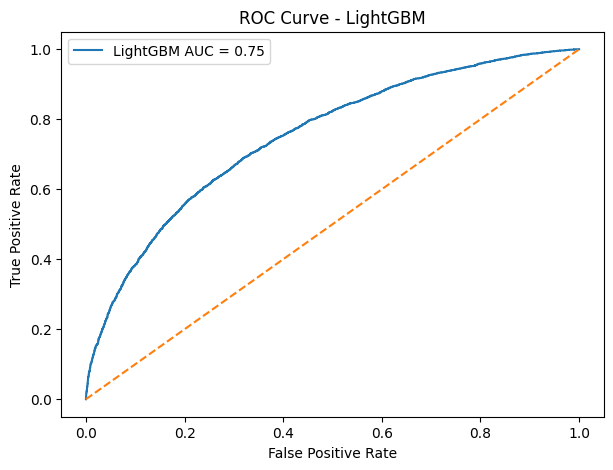

In [48]:
# Step No 22 : Create ROC Curve
# Calculate False Positive Rate and True Positive Rate 
fpr , tpr, thresholds = roc_curve(
    y_test , 
    y_pred_proba
)
# Set figure size 
plt.figure(figsize=(7,5))

# Plot ROC curve
plt.plot(
    fpr,
    tpr,
    label=f"LightGBM AUC = {roc_auc:.2f}"
    
)

# Plot random classifier reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle = "--"
)
# Add X-axis label
plt.xlabel("False Positive Rate")

# Add Y-axis label
plt.ylabel("True Positive Rate")

# Add title
plt.title("ROC Curve - LightGBM")

# Display legend 
plt.legend()

# Display graph
plt.show()

In [49]:
# Step No 23 : Feature Importance 
# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    # Store feature names
    "Feature": X.columns,
    
    # Store feature importance values 
    "Importance": lgbm_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
print(feature_importance)

                    Feature  Importance
3              Credit_Score         694
8      Debt_to_Income_Ratio         672
10       Credit_Utilization         647
2          Employment_Years         495
5             Interest_Rate         472
4             Credit_Amount         390
16  Credit_to_Balance_Ratio         370
1             Annual_Income         307
15      Monthly_Loan_Burden         285
11     Bank_Account_Balance         281
9             Late_Payments         278
13     Loan_to_Income_Ratio         261
7            Existing_Loans         247
0                       Age         233
12         Previous_Default         149
17        Late_Payment_Rate         118
6          Loan_Term_Months          34
22    Loan_Purpose_Personal          26
20        Loan_Purpose_Home          16
19   Loan_Purpose_Education          15
21     Loan_Purpose_Medical           7
18    Loan_Purpose_Business           3
14           Monthly_Income           0


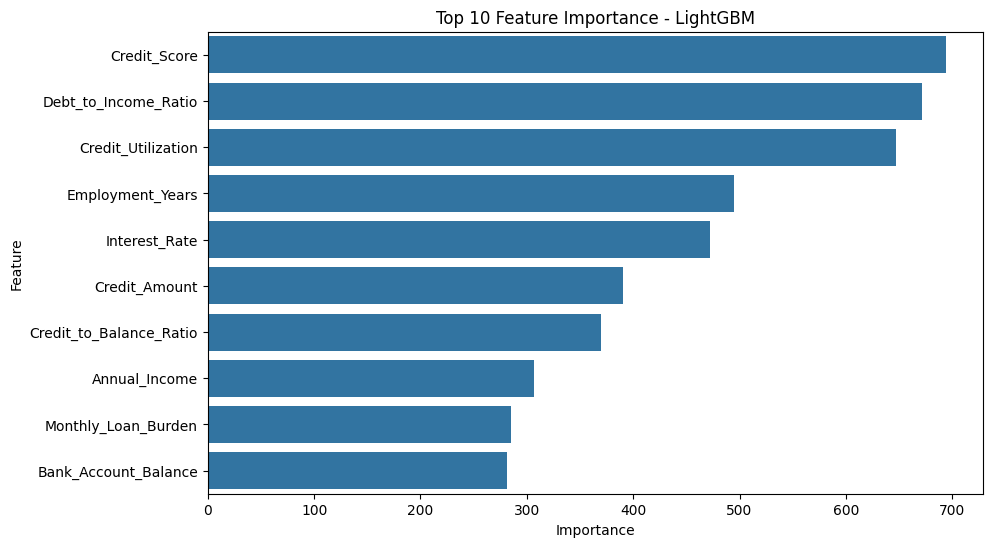

In [52]:
# Step No 24 : Feature Importance Visualization
# Set figure size 
import seaborn as sns
plt.figure(figsize=(10 , 6))

# Plot top 10 important fearures 
sns.barplot(
    x = "Importance",
    y = "Feature",
    data = feature_importance.head(10)
)

# Add title 
plt.title("Top 10 Feature Importance - LightGBM")

# Display graph
plt.show()

In [53]:
# Step No 25 : Display Top 5 Features 
# Display heading 
print("Top 5 Important Features : ")

# Display top 5 important features 
print(feature_importance.head(5))

Top 5 Important Features : 
                 Feature  Importance
3           Credit_Score         694
8   Debt_to_Income_Ratio         672
10    Credit_Utilization         647
2       Employment_Years         495
5          Interest_Rate         472


In [54]:
# Step No 26 : Create New Customer Input 
# Create data for a new customer 
new_customer = pd.DataFrame({
    
    # Customer age 
    "Age": [35],
    
    # Customer annual income
    "Annual_Income": [60000],
    
    # Number of employment years
    "Employment_Years": [8],
    
    # Customer Credit Score 
    "Credit_Score ": [680] , 
    
    # Requested Credit Amount 
    "Credit_Amount": [20000],
    
    # Loan interest rate 
    "Interest_Rate": [10.5],
    
    # Loan Repayment Period
    "Loan_Term_Months": [36],
    
    # Number of existing loans 
    "Existing_Loans": [1],
    
    # Debt-to-income ratio
    "Debt_to_Income_Ration": [0.30],
    
    # Number of late payments
    "Late_Payments": [1],
    
    # Credit utilization ration
    "Credit_Utilization": [0.40],
    
    # Bank Account Balance
    "Bank_Account_Balance": [15000],
    
    # Previous default history
    "Previous_Default": [0],
    
    # Purpose of loan
    "Loan_Purpose":["Personal"]
})

# Display new customer data 
new_customer

,Age,Annual_Income,Employment_Years,Credit_Score,Credit_Amount,Interest_Rate,Loan_Term_Months,Existing_Loans,Debt_to_Income_Ration,Late_Payments,Credit_Utilization,Bank_Account_Balance,Previous_Default,Loan_Purpose
0,35,60000,8,680,20000,10.5,36,1,0.3,1,0.4,15000,0,Personal


In [56]:
# Step No 27 : Apply Same Feature Engineering

# Create Loan-to-Income Ratio
new_customer["Loan_to_Income_Ratio"] = (
    new_customer["Credit_Amount"] /
    (new_customer["Annual_Income"] + 1)
)

# Create Monthly Income
new_customer["Monthly_Income"] = (
    new_customer["Annual_Income"] / 12
)

# Create Monthly Loan Burden
new_customer["Monthly_Loan_Burden"] = (
    new_customer["Credit_Amount"] /
    (new_customer["Loan_Term_Months"] + 1)
)

# Create Credit-to-Balance Ratio
new_customer["Credit_to_Balance_Ratio"] = (
    new_customer["Credit_Amount"] /
    (new_customer["Bank_Account_Balance"] + 1)
)

# Create Late Payment Rate
new_customer["Late_Payment_Rate"] = (
    new_customer["Late_Payments"] /
    (new_customer["Existing_Loans"] + 1)
)

# Display engineered customer data
print(new_customer)

   Age  Annual_Income  Employment_Years  Credit_Score   Credit_Amount  \
0   35          60000                 8            680          20000   

   Interest_Rate  Loan_Term_Months  Existing_Loans  Debt_to_Income_Ration  \
0           10.5                36               1                    0.3   

   Late_Payments  Credit_Utilization  Bank_Account_Balance  Previous_Default  \
0              1                 0.4                 15000                 0   

  Loan_Purpose  Loan_to_Income_Ratio  Monthly_Income  Monthly_Loan_Burden  \
0     Personal              0.333328          5000.0           540.540541   

   Credit_to_Balance_Ratio  Late_Payment_Rate  
0                 1.333244                0.5  


In [57]:
# Step No 28 : Encode New Customer 
# Convert Loan_Purpose  into numerical columns 
new_customer = pd.get_dummies(
    new_customer,
    columns=["Loan_Purpose"],
    drop_first=True
)

# Match new customer columns with training columns
new_customer = new_customer.reindex(
    columns=X.columns,
    fill_value=0
)

# Display final input data 
print(new_customer)

   Age  Annual_Income  Employment_Years  Credit_Score  Credit_Amount  \
0   35          60000                 8             0          20000   

   Interest_Rate  Loan_Term_Months  Existing_Loans  Debt_to_Income_Ratio  \
0           10.5                36               1                     0   

   Late_Payments  ...  Loan_to_Income_Ratio  Monthly_Income  \
0              1  ...              0.333328          5000.0   

   Monthly_Loan_Burden  Credit_to_Balance_Ratio  Late_Payment_Rate  \
0           540.540541                 1.333244                0.5   

   Loan_Purpose_Business  Loan_Purpose_Education  Loan_Purpose_Home  \
0                      0                       0                  0   

   Loan_Purpose_Medical  Loan_Purpose_Personal  
0                     0                      0  

[1 rows x 23 columns]


In [58]:
# Step No 29 : Predict Customer Default 
# Predict whether the customer will default 
new_prediction = lgbm_model.predict(
    new_customer
)
# Calculate probability of default 
new_probability = lgbm_model.predict_proba(
    new_customer
)[0][1]

# Check prediction result 
if new_prediction[0] == 1:
    #Display message when prediction is 1
    print("Customer is likely to DEFAULT.")
else:
    # Display message when prediction is 0 
    print("Customer is NOT likely to DEFAULT")
    
# Display default probability
print(
    "Default Probability : ",
    round(new_probability * 100 , 2),
    "%"
)

Customer is NOT likely to DEFAULT
Default Probability :  25.4 %
